## Imports

In [ ]:
import os
os.environ.setdefault('USE_TF', '0')

import copy
import random

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

from aux_model import SegFormerWithBoundary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cpu


## Load dataset and SegFormer-B0

In [2]:
dataset_val = load_dataset('zhoubolei/scene_parse_150', split='validation', trust_remote_code=True)
print(f'validation samples: {len(dataset_val)}')

validation samples: 2000


In [3]:
MODEL_NAME = 'nvidia/segformer-b0-finetuned-ade-512-512'
processor = SegformerImageProcessor.from_pretrained(MODEL_NAME)
processor.do_reduce_labels = True  # 0 (unlabeled) -> 255 ignore; 1..150 -> 0..149
base_model = SegformerForSemanticSegmentation.from_pretrained(MODEL_NAME)
print(f'loaded: {base_model.config._name_or_path}')

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

loaded: nvidia/segformer-b0-finetuned-ade-512-512


## Load fine-tuned checkpoints

In [ ]:
def load_seg_model(checkpoint_path):
    model = copy.deepcopy(base_model).to(device).eval()
    if checkpoint_path is not None:
        sd = torch.load(checkpoint_path, map_location=device, weights_only=True)
        model.load_state_dict(sd)
    return model

def load_boundary_model(checkpoint_path):
    base = copy.deepcopy(base_model)
    model = SegFormerWithBoundary(base, boundary_hidden=64).to(device).eval()
    sd = torch.load(checkpoint_path, map_location=device, weights_only=True)
    missing, unexpected = model.load_state_dict(sd, strict=False)
    if missing:
        print(f'  [{checkpoint_path}] missing keys: {len(missing)} (e.g. {missing[:3]})')
    if unexpected:
        print(f'  [{checkpoint_path}] unexpected keys: {len(unexpected)} (e.g. {unexpected[:3]})')
    return model

models = {
    'Pretrained':            load_seg_model(None),
    'CE':                         load_seg_model('checkpoints/segformer_ce_10e.pt'),
    'CE + Aux':         load_boundary_model('checkpoints/segformer_boundary_ce_v2_10e.pt'),
    'CE + B-DoU':                 load_seg_model('checkpoints/segformer_ce_bdou_10e.pt'),
    'CE + B-DoU + Aux': load_boundary_model('checkpoints/segformer_boundary_ce_bdou_10e.pt'),
}
print('loaded:', list(models))

loaded: ['Pretrained', 'CE', 'CE + Aux', 'CE + B-DoU', 'CE + B-DoU + Aux']


## Visualize

sample idx=1169, image size=(683, 512), gt shape=(512, 683)
done; pred shape: (512, 683)


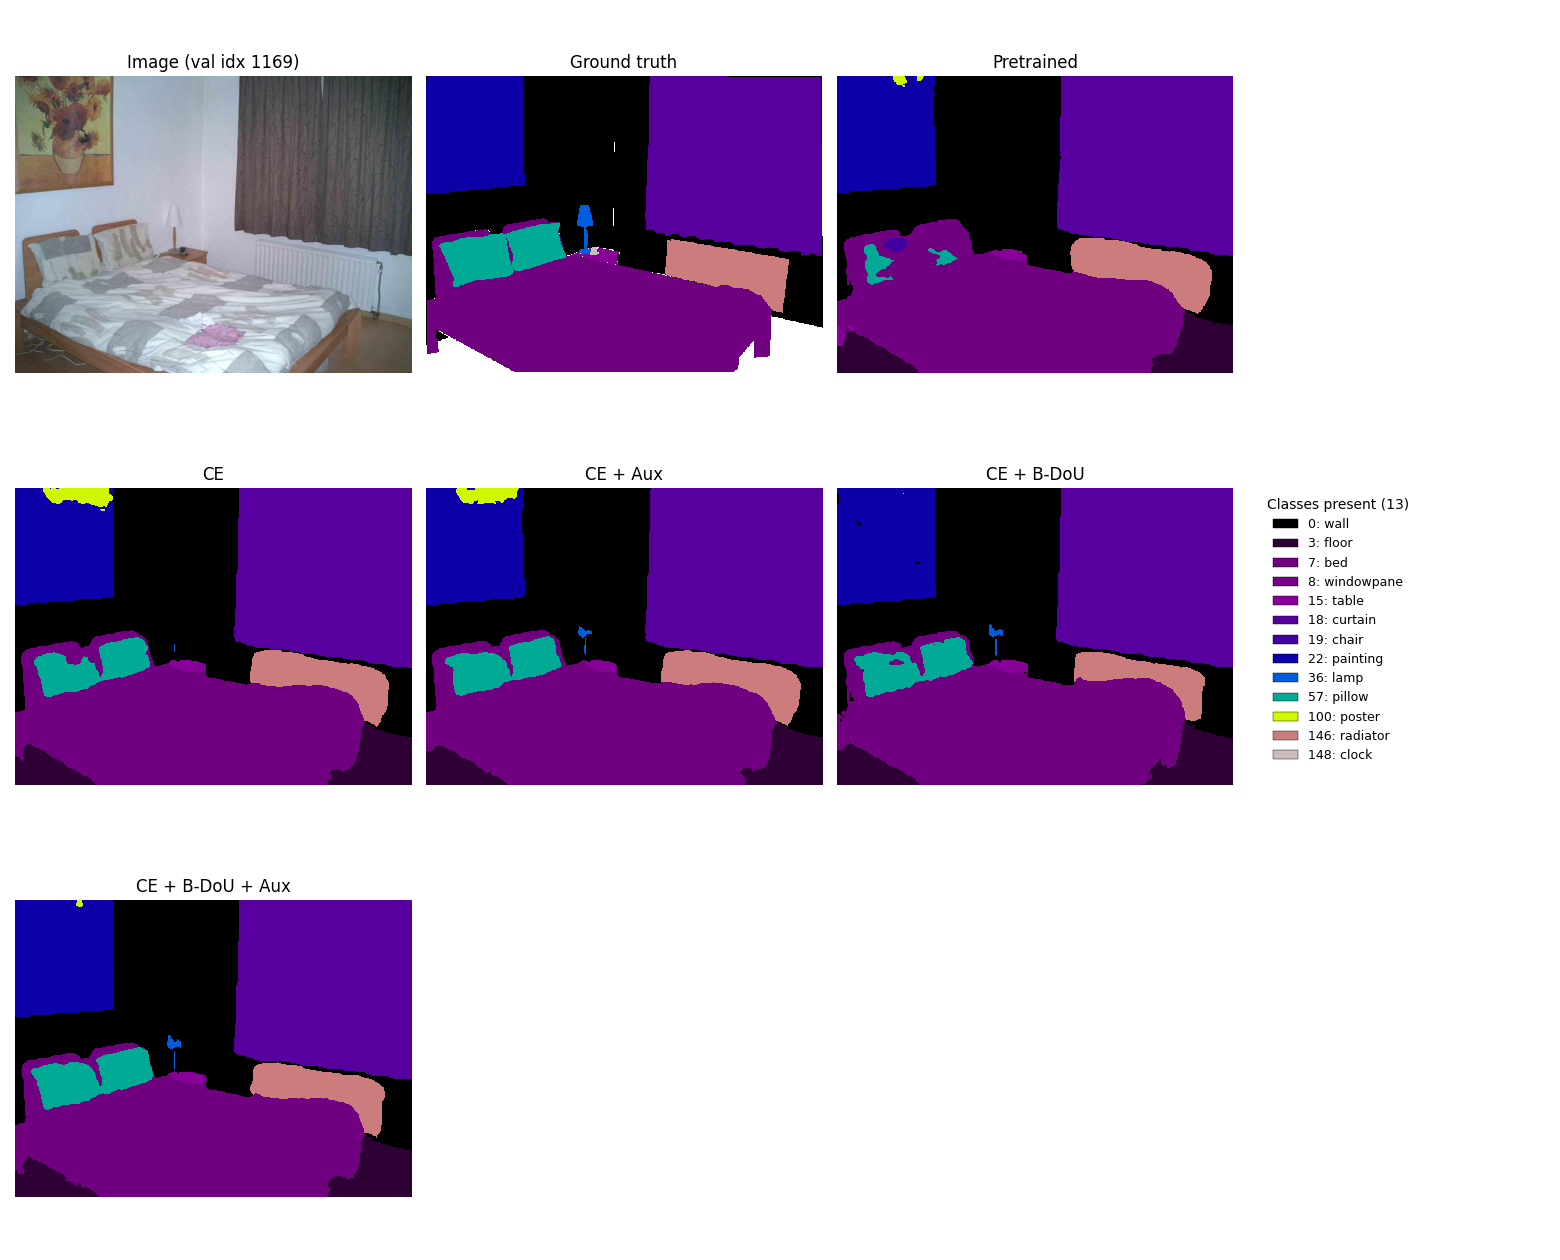

In [ ]:
idx = random.randrange(len(dataset_val))
idx = 1169
sample = dataset_val[idx]
image = sample['image'].convert('RGB')
gt_raw = np.array(sample['annotation'])  # 0 = unlabeled, 1..150 = classes

gt = gt_raw.astype(np.int64) - 1
gt[gt < 0] = 255

print(f'sample idx={idx}, image size={image.size}, gt shape={gt.shape}')

## Inference on every model

@torch.no_grad()
def predict(model, image):
    enc = processor(images=image, return_tensors='pt')
    pixel_values = enc['pixel_values'].to(device)
    out = model(pixel_values=pixel_values)
    H, W = image.size[1], image.size[0]
    logits = F.interpolate(out.logits, size=(H, W), mode='bilinear', align_corners=False)
    return logits.argmax(dim=1).squeeze(0).cpu().numpy()

preds = {name: predict(m, image) for name, m in models.items()}
print('done; pred shape:', next(iter(preds.values())).shape)

## PLOTTING
from matplotlib.patches import Patch

id2label = base_model.config.id2label  # ADE20K class names, keyed by 0..149
cmap = plt.get_cmap('nipy_spectral')
norm = plt.Normalize(vmin=0, vmax=149)

def show_mask(ax, mask, title):
    m = mask.astype(np.float32)
    m[m == 255] = np.nan  # ignore -> transparent
    ax.imshow(m, cmap=cmap, norm=norm, interpolation='nearest')
    ax.set_title(title)
    ax.axis('off')

panels = [('Image', image), ('Ground truth', gt)] + list(preds.items())
n_cols = 3
n_rows = int(np.ceil(len(panels) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4.2 * n_cols + 3.0, 4.2 * n_rows))
axes = np.atleast_2d(axes).flatten()

axes[0].imshow(image)
axes[0].set_title(f'Image (val idx {idx})')
axes[0].axis('off')

for ax, (title, payload) in zip(axes[1:], panels[1:]):
    show_mask(ax, payload, title)

for ax in axes[len(panels):]:
    ax.axis('off')

present = set()
for arr in [gt, *preds.values()]:
    present.update(int(c) for c in np.unique(arr) if c != 255)
handles = [Patch(facecolor=cmap(norm(c)), edgecolor='black', linewidth=0.3,
                 label=f'{c}: {id2label[c]}')
           for c in sorted(present)]

legend_strip = 0.80  # fraction of figure width devoted to panels
fig.tight_layout(rect=(0, 0, legend_strip, 1))
fig.legend(handles=handles, loc='center left',
           bbox_to_anchor=(legend_strip + 0.005, 0.5),
           frameon=False, fontsize=9,
           title=f'Classes present ({len(handles)})')

plt.show()


In [ ]:
from metrics import MetricTracker
from run_experiments import print_results_table

gt_t = torch.from_numpy(gt).long().unsqueeze(0)

single_image_results = {}
for name, pred in preds.items():
    tracker = MetricTracker(num_classes=150, ignore_index=255,
                            device=torch.device('cpu'))
    pred_t = torch.from_numpy(pred).long().unsqueeze(0)
    tracker.update(pred_t, gt_t)
    single_image_results[name] = tracker.compute()

print(f'metrics on val idx {idx} (single image)')
print_results_table(single_image_results)

metrics on val idx 1169 (single image)

Configuration                mIoU      BF1@3      BF1@5      BF1@9     BF1@12       BIoU
----------------------------------------------------------------------------------------
Pretrained                 0.5548     0.5688     0.6509     0.7560     0.7944     0.3081
CE                         0.6275     0.6366     0.7150     0.7745     0.7925     0.4072
CE + Aux                   0.6534     0.6172     0.7091     0.7807     0.7991     0.4276
CE + B-DoU                 0.6734     0.6764     0.7463     0.7984     0.8265     0.4170
CE + B-DoU + Aux           0.6834     0.6898     0.7670     0.8153     0.8463     0.4799


## Visualize boundary-head outputs

In [ ]:
from aux_model import compute_boundary_target

@torch.no_grad()
def predict_boundary(model, image):
    enc = processor(images=image, return_tensors='pt')
    pixel_values = enc['pixel_values'].to(device)
    out = model(pixel_values=pixel_values)
    H, W = image.size[1], image.size[0]
    bnd_logits = F.interpolate(out.boundary_logits, size=(H, W),
                               mode='bilinear', align_corners=False)
    return torch.sigmoid(bnd_logits).squeeze().cpu().numpy()

boundary_models = {
    name: m for name, m in models.items() if 'boundary head' in name
}

gt_boundary = compute_boundary_target(
    torch.from_numpy(gt).long().unsqueeze(0), ignore_index=255
).squeeze().numpy()

bnd_preds = {name: predict_boundary(m, image) for name, m in boundary_models.items()}
print('boundary models:', list(bnd_preds))
print('gt boundary pixel ratio:', f'{gt_boundary.mean():.4f}')

boundary models: []
gt boundary pixel ratio: 0.0226


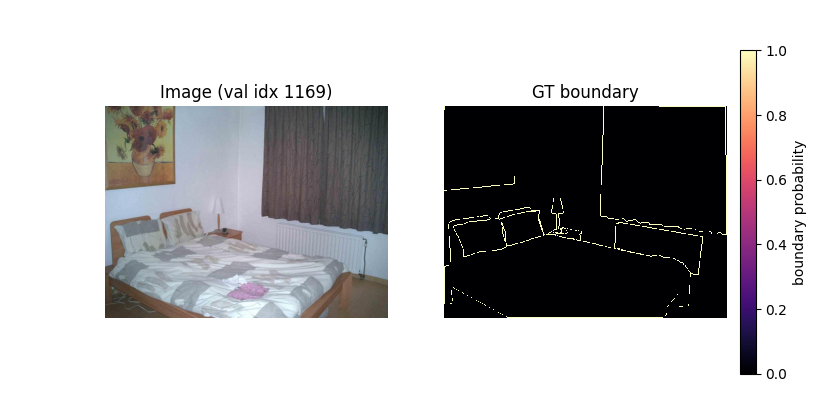

In [ ]:
bnd_panels = [('Image', image), ('GT boundary', gt_boundary)] + list(bnd_preds.items())
n_cols = len(bnd_panels)
fig, axes = plt.subplots(1, n_cols, figsize=(4.2 * n_cols, 4.2))
axes = np.atleast_1d(axes)

axes[0].imshow(image)
axes[0].set_title(f'Image (val idx {idx})')
axes[0].axis('off')

im = None
for ax, (title, payload) in zip(axes[1:], bnd_panels[1:]):
    im = ax.imshow(payload, cmap='magma', vmin=0.0, vmax=1.0, interpolation='nearest')
    ax.set_title(title)
    ax.axis('off')

cbar = fig.colorbar(im, ax=axes.tolist(), fraction=0.025, pad=0.02)
cbar.set_label('boundary probability')
plt.show()

## Interactive overlay the predicted boundary on the ground truth

In [ ]:
%matplotlib widget

def derive_seg_boundary(pred_argmax):
    t = torch.from_numpy(pred_argmax).long().unsqueeze(0)
    return compute_boundary_target(t, ignore_index=255).squeeze().numpy()


def compare_boundaries(idx, models, n_cols=3, panel_size=4.5):
    sample = dataset_val[idx]
    image_local = sample['image'].convert('RGB')
    gt_raw_local = np.array(sample['annotation'])
    gt_local = gt_raw_local.astype(np.int64) - 1
    gt_local[gt_local < 0] = 255
    gt_bnd = compute_boundary_target(
        torch.from_numpy(gt_local).long().unsqueeze(0), ignore_index=255
    ).squeeze().numpy()

    panels = [('Ground truth', gt_bnd)]
    for name, m in models.items():
        seg_argmax = predict(m, image_local)        # always the seg head
        panels.append((name, derive_seg_boundary(seg_argmax)))

    n = len(panels)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(panel_size * n_cols, panel_size * n_rows),
        sharex=True, sharey=True,  # synchronized zoom across panels
    )
    axes = np.atleast_1d(axes).flatten()

    image_gray = np.array(image_local.convert('L'))

    red_rgb = (1.0, 0.0, 0.0)
    cyan_rgb = (0.0, 1.0, 1.0)
    pred_alpha = 0.6
    gt_alpha = 0.55

    def line_overlay(mask, rgb, alpha):
        out = np.zeros((*mask.shape, 4), dtype=np.float32)
        out[..., 0] = rgb[0]
        out[..., 1] = rgb[1]
        out[..., 2] = rgb[2]
        out[..., 3] = (mask > 0.5).astype(np.float32) * alpha
        return out

    gt_overlay = line_overlay(gt_bnd, cyan_rgb, gt_alpha)

    for ax, (title, bnd) in zip(axes, panels):
        ax.imshow(image_gray, cmap='gray', vmin=0, vmax=255,
                  interpolation='nearest', alpha=0.55)
        if title == 'Ground truth':
            ax.imshow(gt_overlay, interpolation='nearest')
        else:
            ax.imshow(line_overlay(bnd, red_rgb, pred_alpha),
                      interpolation='nearest')
            ax.imshow(gt_overlay, interpolation='nearest')  # GT on top
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes[n:]:
        ax.axis('off')

    fig.suptitle(f'val idx {idx}  |  predicted (from seg argmax): red,  GT boundary: cyan',
                 fontsize=11)
    fig.tight_layout()
    return fig


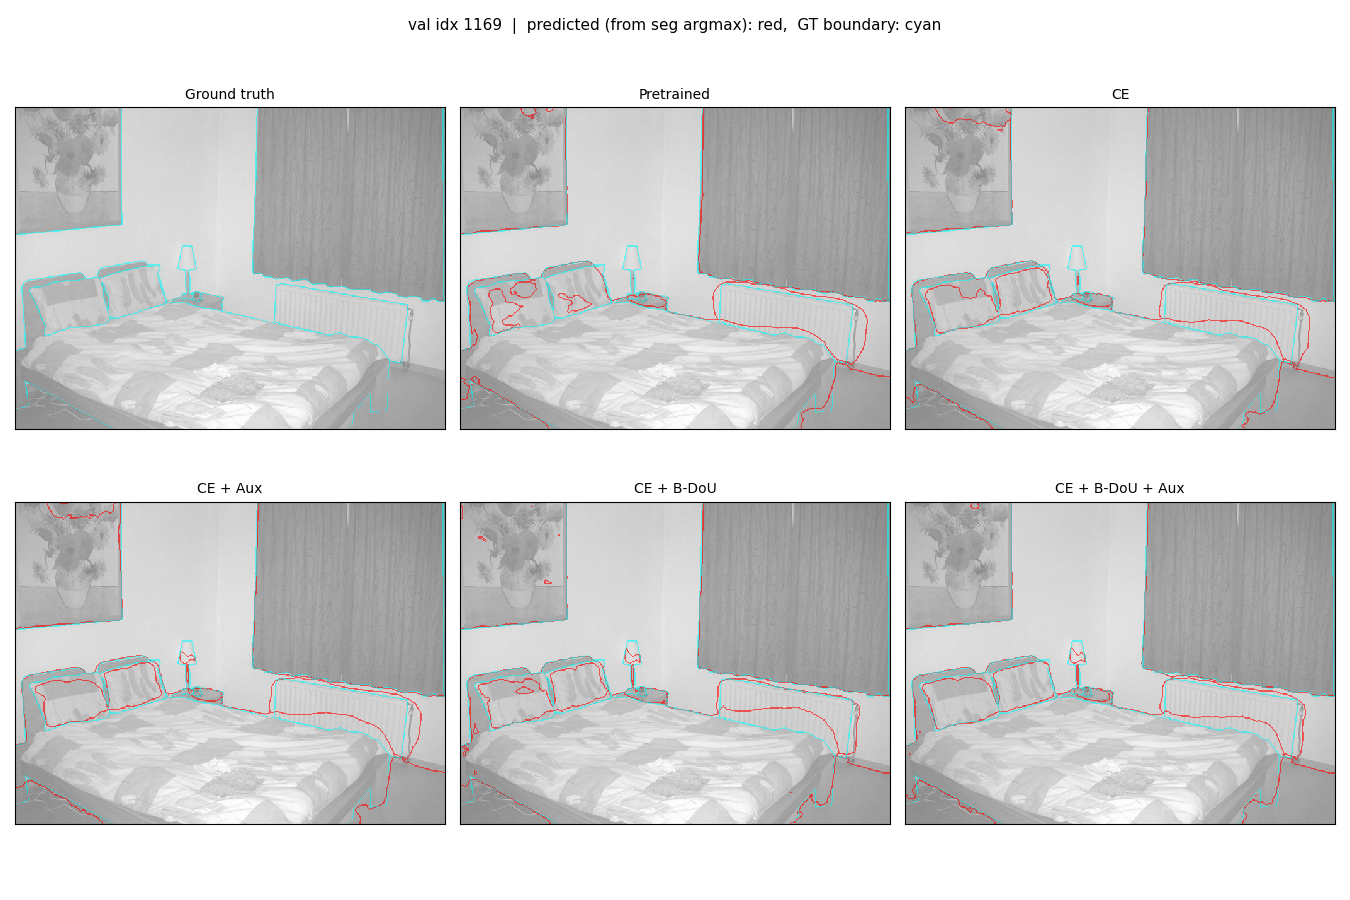

In [42]:
# Reuse the idx picked above, or set one explicitly to compare a specific image.
idx = random.randrange(len(dataset_val))
idx = 1169
fig = compare_boundaries(idx, models)
# fig = compare_boundaries(923, models)  # example: lock to a known image